# 05 — Proposed Model, Tuning and Final Evaluation (Review 2)

**Owner: Akilan (modelling)**

**Proposed model: XGBoost on the selected engineered features**, with a tuned decision threshold.
Why XGBoost: it was the best Review 1 model on the two threshold-free metrics (ROC-AUC, AUPRC),
it handles missing values natively (so we keep the information in "never measured"),
and gradient-boosted trees were among the most common and best-performing approaches in the PhysioNet 2019 challenge.

**How the improvement is shown (an ablation).** Each row adds one thing, so every gain can be attributed:

| Stage | What changes |
|---|---|
| A | Review 1 XGBoost as reported (raw 40 features, threshold 0.5) |
| B | Same raw 40 features + tuned threshold |
| C | + engineered features |
| D | + feature selection |
| E | + hyperparameter tuning  → **final proposed model** |
| F | PCA variant (dimensionality-reduction comparison) |

Stage B uses the same 40 inputs as Review 1 (forward-filled, missing values left as NaN instead of median-filled), trained on 85 % of the training patients with early stopping on the other 15 %.

Stage A and the Review 1 Logistic Regression row are loaded live from notebook 02's saved results (never hardcoded), so this notebook can never go stale relative to Review 1.

**Fair evaluation rules.** Threshold and hyperparameters are chosen on the validation patients only.
The test patients are used once, for the final numbers.
To keep memory low, the training rows keep all positive hours and 40 % of the negative hours (`NEG_FRACTION`); validation and test rows are never sampled.
Accuracy is reported but not used to judge models (predicting "never septic" already scores 98.2 %).

In [1]:
# CELL 1 — Imports, settings and paths
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.model_selection import ParameterSampler
from xgboost import XGBClassifier

from pathlib import Path

import gc
import warnings
warnings.filterwarnings("ignore")

N_ITER = 8             # hyperparameter settings to try (each one is a full training run)
# TARGET_RECALL is set in CELL 3 below, from Review 1's actual Logistic Regression recall
# (never hardcoded, so it always matches whatever notebook 02 actually produced).

# Memory saver: keep every sepsis-positive hour but only this share of the negative hours
# in the training rows (same idea as notebook 04). Set to 1.0 if you have plenty of RAM.
# Validation and test rows are never sampled.
NEG_FRACTION = 0.4

# All paths are relative to the repository root, so the notebook works on any machine
def find_project_root():
    here = Path.cwd()
    for folder in [here, here.parent]:
        if (folder / "notebooks").is_dir():
            return folder
    raise FileNotFoundError("Open this notebook from the repository root or from the notebooks/ folder.")

PROJECT_ROOT = find_project_root()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
for folder in [METRICS_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(folder, exist_ok=True)

In [2]:
# CELL 2 — Load data, feature sets and the validation split from notebook 04
train = joblib.load(os.path.join(PROC_DIR, "review2_train.joblib"))
test = joblib.load(os.path.join(PROC_DIR, "review2_test.joblib"))
split = joblib.load(os.path.join(PROC_DIR, "review2_split.joblib"))

with open(os.path.join(PROC_DIR, "review2_feature_sets.json")) as f:
    feature_sets = json.load(f)

raw_cols = feature_sets["raw_cols"]
filtered_cols = feature_sets["filtered_cols"]
selected_features = feature_sets["selected_features"]

is_fit = train["meta"]["Patient_Key"].isin(split["fit_keys"]).values
is_val = train["meta"]["Patient_Key"].isin(split["val_keys"]).values

# Validation rows are kept in full
X_val, y_val = train["X"][is_val], train["y"][is_val]

# Fit rows: all positive hours + a random share of the negative hours
rng = np.random.default_rng(42)
keep_negative = rng.random(len(train["y"])) < NEG_FRACTION
keep_fit = is_fit & ((train["y"].values == 1) | keep_negative)
X_fit, y_fit = train["X"][keep_fit], train["y"][keep_fit]

X_test, y_test = test["X"], test["y"]
meta_test = test["meta"]

# Free the big original training matrix - it is not needed any more
del train, test, rng, keep_negative
gc.collect()

print("Fit rows :", X_fit.shape[0])
print("Val rows :", X_val.shape[0])
print("Test rows:", X_test.shape[0])
print("Raw features:", len(raw_cols), "| Filtered:", len(filtered_cols), "| Selected:", len(selected_features))

Fit rows : 324860
Val rows : 139219
Test rows: 232513
Raw features: 40 | Filtered: 119 | Selected: 15


In [3]:
# CELL 3 — Review 1 results, loaded live from notebook 02's own saved output
# (never hardcoded here - this always matches whatever notebook 02 actually produced
# on this machine, so Stage A below can never go stale relative to Review 1).
review1_path = METRICS_DIR / "traditional_model_comparison.csv"
if not review1_path.exists():
    raise FileNotFoundError(
        f"Could not find {review1_path.relative_to(PROJECT_ROOT)} - "
        "run notebook 02 (Traditional_Model_Comparison) first; it saves this file."
    )

review1 = pd.read_csv(review1_path).rename(columns={"F1-Score": "F1"})

required_models = {"XGBoost", "Logistic Regression"}
missing = required_models - set(review1["Model"])
if missing:
    raise ValueError(f"notebook 02's results are missing expected model(s): {missing}")

# The "matched recall" comparison target is read from Review 1's actual Logistic
# Regression recall - not a hardcoded guess - so it is always exactly correct,
# whatever number notebook 02 produced on this run.
TARGET_RECALL = float(review1.loc[review1["Model"] == "Logistic Regression", "Recall"].iloc[0])
print(f"Target recall for the matched-recall comparison (from Review 1 Logistic Regression): {TARGET_RECALL:.4f}")

display(review1.round(4))

Target recall for the matched-recall comparison (from Review 1 Logistic Regression): 0.5941


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,AUPRC
0,XGBoost,0.9792,0.1063,0.0323,0.0495,0.8085,0.0768
1,HistGradientBoosting,0.9766,0.0945,0.0461,0.0620,0.8052,0.0712
2,Random Forest,0.9437,0.0955,0.2778,0.1421,0.7790,0.0689
3,Logistic Regression,0.7499,0.0394,0.5941,0.0738,0.7157,0.0610
4,Decision Tree,0.8090,0.0475,0.5454,0.0875,0.6453,0.0564


In [4]:
# CELL 4 — Helper functions
def metrics_at(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_true, pred, zero_division=0),
        "F2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

def best_threshold(y_true, prob, beta=2):
    """Threshold with the best F-beta score. beta=2 weights recall twice as much as precision."""
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    precision, recall = precision[:-1], recall[:-1]
    fbeta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall + 1e-12)
    return float(thresholds[fbeta.argmax()])

def threshold_for_recall(y_true, prob, target):
    """Highest threshold that still reaches the target recall."""
    _, recall, thresholds = precision_recall_curve(y_true, prob)
    ok = np.where(recall[:-1] >= target)[0]
    return float(thresholds[ok[-1]])

negatives = (y_fit == 0).sum()
positives = (y_fit == 1).sum()
SPW = float(np.sqrt(negatives / positives))

DEFAULT_PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SPW, tree_method="hist", eval_metric="aucpr",
    early_stopping_rounds=30, n_jobs=-1, random_state=42,
)

def fit_xgb(cols, new_params=None):
    params = dict(DEFAULT_PARAMS)
    if new_params is not None:
        params.update(new_params)
    model = XGBClassifier(**params)
    model.fit(X_fit[cols], y_fit, eval_set=[(X_val[cols], y_val)], verbose=False)
    return model

print("scale_pos_weight:", round(SPW, 2))

scale_pos_weight: 4.82


In [5]:
# CELL 5 — Stages B, C, D: same XGBoost settings, only the input features change
stage_features = {
    "B: Raw 40 features + tuned threshold": raw_cols,
    "C: + Engineered features": filtered_cols,
    "D: + Feature selection": selected_features,
}

val_probs = {}
test_probs = {}

for name, cols in stage_features.items():
    model = fit_xgb(cols)
    val_probs[name] = model.predict_proba(X_val[cols])[:, 1]
    test_probs[name] = model.predict_proba(X_test[cols])[:, 1]
    print(f"{name}: {len(cols)} features, trees used = {model.best_iteration + 1}")

B: Raw 40 features + tuned threshold: 40 features, trees used = 13
C: + Engineered features: 119 features, trees used = 17
D: + Feature selection: 15 features, trees used = 83


In [6]:
# CELL 6 — Stage E: hyperparameter tuning on the selected features (validation AUPRC)
PARAM_GRID = {
    "max_depth": [4, 5, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 20],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1.0, SPW, 2 * SPW],
}

search_rows = []
best_score = -1
best_model = None
best_params = None

for i, params in enumerate(ParameterSampler(PARAM_GRID, n_iter=N_ITER, random_state=42), start=1):
    params = dict(params)
    params["n_estimators"] = 800
    model = fit_xgb(selected_features, params)

    prob = model.predict_proba(X_val[selected_features])[:, 1]
    score = average_precision_score(y_val, prob)

    search_rows.append({**params, "Val_AUPRC": score, "Val_ROC_AUC": roc_auc_score(y_val, prob),
                        "Trees": model.best_iteration + 1})
    print(f"[{i}/{N_ITER}] Val AUPRC {score:.4f} | {params}")

    if score > best_score:
        best_score = score
        best_model = model
        best_params = params

search_results = pd.DataFrame(search_rows).sort_values("Val_AUPRC", ascending=False)
search_results.to_csv(os.path.join(METRICS_DIR, "review2_hyperparameter_search.csv"), index=False)

print("\nBest validation AUPRC:", round(best_score, 4))
print("Best parameters:", best_params)

final_name = "E: + Tuned hyperparameters (FINAL)"
val_probs[final_name] = best_model.predict_proba(X_val[selected_features])[:, 1]
test_probs[final_name] = best_model.predict_proba(X_test[selected_features])[:, 1]

[1/8] Val AUPRC 0.1272 | {'subsample': 1.0, 'scale_pos_weight': 4.823569842476459, 'reg_lambda': 10, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.5, 'n_estimators': 800}
[2/8] Val AUPRC 0.1177 | {'subsample': 0.8, 'scale_pos_weight': 9.647139684952919, 'reg_lambda': 10, 'min_child_weight': 20, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7, 'n_estimators': 800}
[3/8] Val AUPRC 0.1213 | {'subsample': 1.0, 'scale_pos_weight': 4.823569842476459, 'reg_lambda': 10, 'min_child_weight': 20, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7, 'n_estimators': 800}
[4/8] Val AUPRC 0.1263 | {'subsample': 0.7, 'scale_pos_weight': 9.647139684952919, 'reg_lambda': 5, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7, 'n_estimators': 800}
[5/8] Val AUPRC 0.1161 | {'subsample': 0.7, 'scale_pos_weight': 1.0, 'reg_lambda': 10, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytre

In [7]:
# CELL 7 — Stage F: PCA variant (from notebook 04)
pipeline = joblib.load(os.path.join(PROC_DIR, "review2_pca_pipeline.joblib"))

def pca_transform(X, chunk=200_000):
    parts = []
    for start in range(0, len(X), chunk):
        block = X[pipeline["cols"]].iloc[start:start + chunk].fillna(pipeline["medians"])
        parts.append(pipeline["pca"].transform(pipeline["scaler"].transform(block)).astype("float32"))
    return np.vstack(parts)

X_fit_pca = pca_transform(X_fit)
X_val_pca = pca_transform(X_val)
X_test_pca = pca_transform(X_test)

pca_model = XGBClassifier(**DEFAULT_PARAMS)
pca_model.fit(X_fit_pca, y_fit, eval_set=[(X_val_pca, y_val)], verbose=False)

pca_name = "F: PCA + XGBoost"
val_probs[pca_name] = pca_model.predict_proba(X_val_pca)[:, 1]
test_probs[pca_name] = pca_model.predict_proba(X_test_pca)[:, 1]

print("PCA components used:", X_fit_pca.shape[1])

PCA components used: 71


In [8]:
# CELL 8 — Final ablation table on the TEST patients
# Threshold for every stage is chosen on validation (best F2), then applied once to test.

rows = []

# Stage A: Review 1 XGBoost as reported (threshold 0.5)
xgb_r1 = review1[review1["Model"] == "XGBoost"].iloc[0]
rows.append({
    "Stage": "A: Review 1 XGBoost (reported)", "Threshold": 0.5,
    "Accuracy": xgb_r1["Accuracy"], "Precision": xgb_r1["Precision"], "Recall": xgb_r1["Recall"],
    "F1": xgb_r1["F1"], "F2": np.nan, "ROC-AUC": xgb_r1["ROC-AUC"], "AUPRC": xgb_r1["AUPRC"],
    "Acc @ matched recall": np.nan, "Prec @ matched recall": np.nan,
})

for name in test_probs:
    thr = best_threshold(y_val, val_probs[name], beta=2)
    row = metrics_at(y_test, test_probs[name], thr)

    # Equal-recall comparison: reads one point off the test PR curve (a comparison, not a tuning step)
    thr_fixed = threshold_for_recall(y_test, test_probs[name], TARGET_RECALL)
    fixed = metrics_at(y_test, test_probs[name], thr_fixed)

    rows.append({
        "Stage": name, "Threshold": thr,
        "Accuracy": row["Accuracy"], "Precision": row["Precision"], "Recall": row["Recall"],
        "F1": row["F1"], "F2": row["F2"],
        "ROC-AUC": roc_auc_score(y_test, test_probs[name]),
        "AUPRC": average_precision_score(y_test, test_probs[name]),
        "Acc @ matched recall": fixed["Accuracy"], "Prec @ matched recall": fixed["Precision"],
    })

# Review 1's class-weighted Logistic Regression is the only Review 1 model close
# to the final model's recall, so it's the fairest like-for-like baseline here.
lr_r1 = review1[review1["Model"] == "Logistic Regression"].iloc[0]
rows.insert(1, {
    "Stage": "Review 1 Logistic Regression (reported)", "Threshold": 0.5,
    "Accuracy": lr_r1["Accuracy"], "Precision": lr_r1["Precision"], "Recall": lr_r1["Recall"],
    "F1": lr_r1["F1"], "F2": np.nan, "ROC-AUC": lr_r1["ROC-AUC"], "AUPRC": lr_r1["AUPRC"],
    "Acc @ matched recall": lr_r1["Accuracy"], "Prec @ matched recall": lr_r1["Precision"],
})

ablation = pd.DataFrame(rows)
ablation.to_csv(os.path.join(METRICS_DIR, "review2_ablation_test.csv"), index=False)

pd.set_option("display.width", 200)
display(ablation.round(4))

,Stage,Threshold,Accuracy,Precision,Recall,F1,F2,ROC-AUC,AUPRC,Acc @ matched recall,Prec @ matched recall
0,A: Review 1 XGBoost (reported),0.5000,0.9792,0.1063,0.0323,0.0495,NaN,0.8085,0.0768,NaN,NaN
1,Review 1 Logistic Regression (reported),0.5000,0.7499,0.0394,0.5941,0.0738,NaN,0.7157,0.0610,0.7499,0.0394
2,B: Raw 40 features + tuned threshold,0.3171,0.9300,0.1023,0.4077,0.1635,0.2553,0.8180,0.0941,0.8414,0.0616
3,C: + Engineered features,0.3064,0.9187,0.0991,0.4751,0.1639,0.2701,0.8386,0.1121,0.8713,0.0756
4,D: + Feature selection,0.4505,0.9450,0.1178,0.3511,0.1764,0.2515,0.8343,0.1117,0.8605,0.0699
5,E: + Tuned hyperparameters (FINAL),0.3748,0.9256,0.0987,0.4218,0.1599,0.2549,0.8341,0.1128,0.8657,0.0725
6,F: PCA + XGBoost,0.2847,0.9145,0.0759,0.3667,0.1258,0.2077,0.7678,0.0659,0.8106,0.0518


In [9]:
# CELL 9 — How much did we improve? (Stage A -> final model)
final_row = ablation[ablation["Stage"] == final_name].iloc[0]
base_row = ablation[ablation["Stage"] == "A: Review 1 XGBoost (reported)"].iloc[0]
lr_row = ablation[ablation["Stage"] == "Review 1 Logistic Regression (reported)"].iloc[0]

print("THRESHOLD-FREE (fair regardless of operating point)")
for metric in ["ROC-AUC", "AUPRC"]:
    before, after = base_row[metric], final_row[metric]
    print(f"  {metric:8s}: {before:.4f} -> {after:.4f}  ({(after - before) / before * 100:+.1f}%)")

print(f"\nAT THE SAME RECALL ({TARGET_RECALL*100:.1f}%) AS THE REVIEW 1 LOGISTIC REGRESSION")
for label, column in [("Accuracy", "Acc @ matched recall"), ("Precision", "Prec @ matched recall")]:
    before, after = lr_row[column], final_row[column]
    print(f"  {label:9s}: {before:.4f} -> {after:.4f}  ({(after - before) / before * 100:+.1f}%)")

print("\nAT THE TUNED CLINICAL THRESHOLD (best F2)")
for metric in ["Recall", "Precision", "F1"]:
    before, after = base_row[metric], final_row[metric]
    print(f"  {metric:9s}: {before:.4f} -> {after:.4f}")

THRESHOLD-FREE (fair regardless of operating point)
  ROC-AUC : 0.8085 -> 0.8341  (+3.2%)
  AUPRC   : 0.0768 -> 0.1128  (+46.8%)

AT THE SAME RECALL (59.4%) AS THE REVIEW 1 LOGISTIC REGRESSION
  Accuracy : 0.7499 -> 0.8657  (+15.4%)
  Precision: 0.0394 -> 0.0725  (+84.2%)

AT THE TUNED CLINICAL THRESHOLD (best F2)
  Recall   : 0.0323 -> 0.4218
  Precision: 0.1063 -> 0.0987
  F1       : 0.0495 -> 0.1599


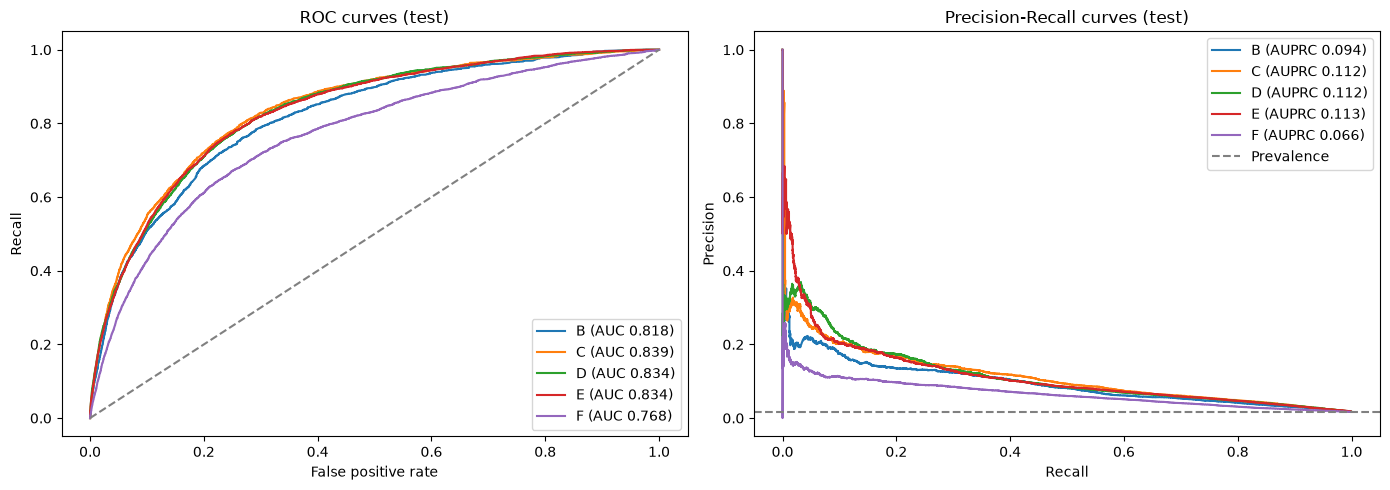

In [10]:
# CELL 10 — Curves: ROC and Precision-Recall on the test patients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob in test_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f"{name[:1]} (AUC {roc_auc_score(y_test, prob):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(recall, precision, label=f"{name[:1]} (AUPRC {average_precision_score(y_test, prob):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("Recall")
axes[0].set_title("ROC curves (test)")
axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_roc_pr_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

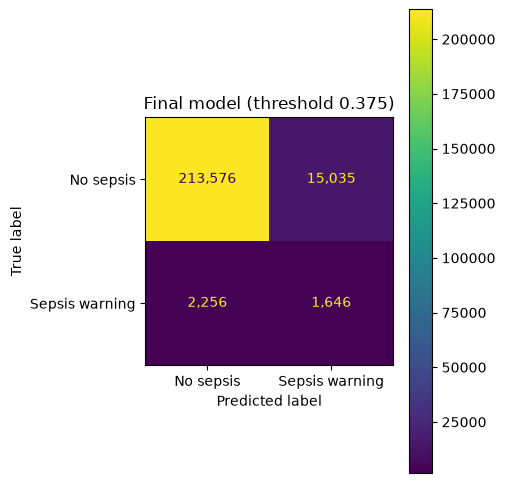

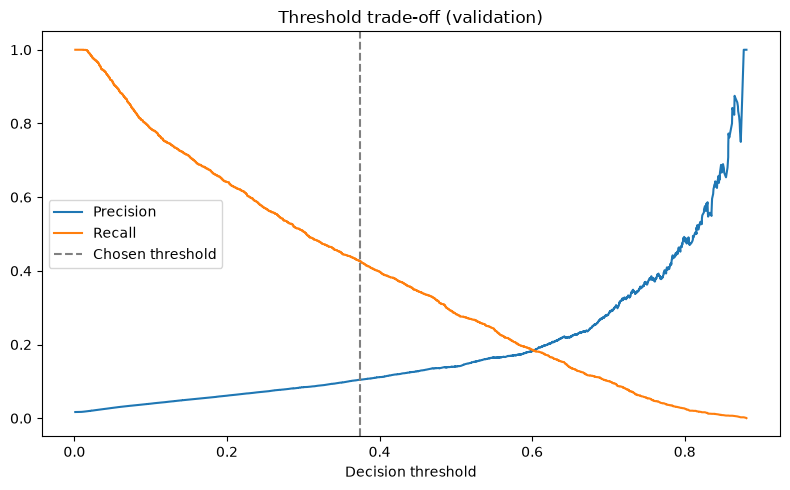

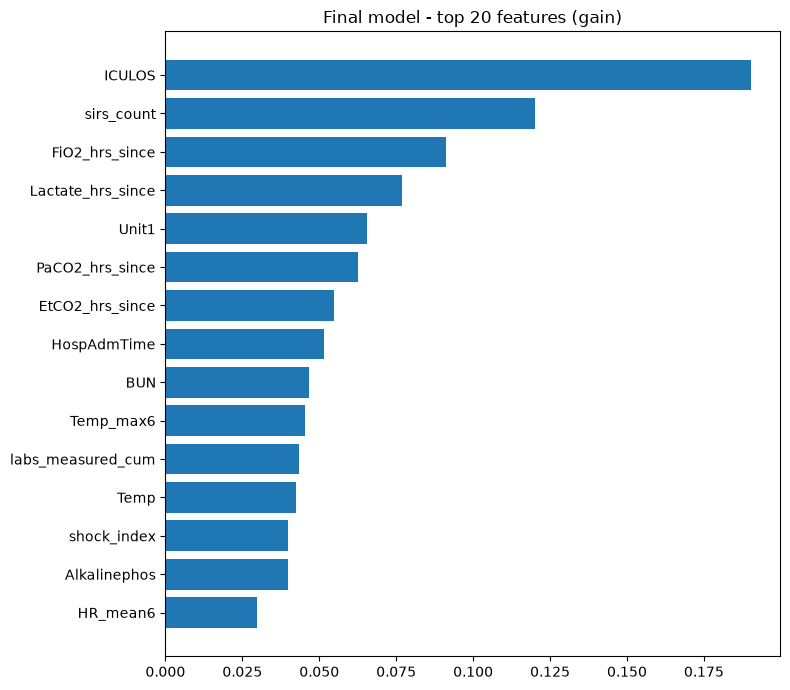

In [11]:
# CELL 11 — Final model: confusion matrix, threshold trade-off, feature importance
final_prob_val = val_probs[final_name]
final_prob_test = test_probs[final_name]
final_threshold = best_threshold(y_val, final_prob_val, beta=2)

final_pred = (final_prob_test >= final_threshold).astype(int)
cm = confusion_matrix(y_test, final_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["No sepsis", "Sepsis warning"]).plot(ax=ax, values_format=",d")
ax.set_title(f"Final model (threshold {final_threshold:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_final_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Precision / recall as the threshold moves (validation data)
precision, recall, thresholds = precision_recall_curve(y_val, final_prob_val)
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(final_threshold, linestyle="--", color="gray", label="Chosen threshold")
plt.xlabel("Decision threshold")
plt.title("Threshold trade-off (validation)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_threshold_tradeoff.png"), dpi=300, bbox_inches="tight")
plt.show()

# Feature importance of the final model
importance = pd.Series(best_model.feature_importances_, index=selected_features).sort_values().tail(20)
plt.figure(figsize=(8, 7))
plt.barh(importance.index, importance.values)
plt.title("Final model - top 20 features (gain)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "review2_final_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# CELL 12 — Patient-level view (what a clinician would experience)
# The dataset labels start 6 hours BEFORE clinical onset, so onset = first positive label hour + 6.

def patient_level_report(meta, y_true, prob, thr):
    data = meta.copy()
    data["y"] = y_true.values
    data["alert"] = prob >= thr

    septic_total = 0
    septic_alerted_by_onset = 0
    lead_times = []
    healthy_total = 0
    healthy_with_alert = 0

    for key, g in data.groupby("Patient_Key"):
        alert_hours = g.loc[g["alert"], "ICULOS"]

        if g["y"].max() == 1:
            septic_total += 1
            onset = g.loc[g["y"] == 1, "ICULOS"].min() + 6
            if len(alert_hours) > 0 and alert_hours.min() <= onset:
                septic_alerted_by_onset += 1
                lead_times.append(onset - alert_hours.min())
        else:
            healthy_total += 1
            if len(alert_hours) > 0:
                healthy_with_alert += 1

    print("Septic patients                       :", septic_total)
    print("  alerted at or before onset          : %d (%.1f%%)" % (septic_alerted_by_onset, 100 * septic_alerted_by_onset / septic_total))
    if len(lead_times) > 0:
        print("  median warning time before onset    : %.1f hours" % np.median(lead_times))
    print("Non-septic patients                   :", healthy_total)
    print("  with at least one false alert       : %d (%.1f%%)" % (healthy_with_alert, 100 * healthy_with_alert / healthy_total))

print("FINAL MODEL at threshold %.3f" % final_threshold)
patient_level_report(meta_test, y_test, final_prob_test, final_threshold)

baseline_name = "B: Raw 40 features + tuned threshold"
baseline_threshold = best_threshold(y_val, val_probs[baseline_name], beta=2)
print("\nSTAGE B (raw features) at threshold %.3f" % baseline_threshold)
patient_level_report(meta_test, y_test, test_probs[baseline_name], baseline_threshold)

FINAL MODEL at threshold 0.375
Septic patients                       : 413
  alerted at or before onset          : 264 (63.9%)
  median warning time before onset    : 28.0 hours
Non-septic patients                   : 5655
  with at least one false alert       : 817 (14.4%)

STAGE B (raw features) at threshold 0.317
Septic patients                       : 413
  alerted at or before onset          : 212 (51.3%)
  median warning time before onset    : 30.0 hours
Non-septic patients                   : 5655
  with at least one false alert       : 556 (9.8%)


In [13]:
# CELL 13 — Save the final model and summary
joblib.dump(best_model, os.path.join(MODELS_DIR, "review2_final_xgboost.joblib"))

with open(os.path.join(MODELS_DIR, "review2_final_config.json"), "w") as f:
    json.dump({
        "features": selected_features,
        "threshold": final_threshold,
        "xgboost_params": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in best_params.items()},
    }, f, indent=2, default=int)

print("=" * 65)
print("REVIEW 2 - FINAL SUMMARY (test patients)")
print("=" * 65)
print("Proposed model     : XGBoost")
print("Input features     : %d selected from %d engineered" % (len(selected_features), len(filtered_cols)))
print("Decision threshold : %.3f (chosen on validation, best F2)" % final_threshold)
print("ROC-AUC            : %.4f (Review 1 XGBoost: %.4f)" % (final_row["ROC-AUC"], base_row["ROC-AUC"]))
print("AUPRC              : %.4f (Review 1 XGBoost: %.4f)" % (final_row["AUPRC"], base_row["AUPRC"]))
print("Recall / Precision : %.4f / %.4f" % (final_row["Recall"], final_row["Precision"]))
print("Saved to           :", MODELS_DIR.relative_to(PROJECT_ROOT))

REVIEW 2 - FINAL SUMMARY (test patients)
Proposed model     : XGBoost
Input features     : 15 selected from 119 engineered
Decision threshold : 0.375 (chosen on validation, best F2)
ROC-AUC            : 0.8341 (Review 1 XGBoost: 0.8085)
AUPRC              : 0.1128 (Review 1 XGBoost: 0.0768)
Recall / Precision : 0.4218 / 0.0987
Saved to           : results\models
